# 🏠 House Prices — Uçtan Uca Pipeline, Özellik Mühendisliği ve Model Blending

**Yarışma:** [House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) · **Metrik:** RMSLE

Bu notebook adım adım şunları yapar:
1. **Baseline:** tip bazlı basit ön işleme + Decision Tree, özel RMSLE scorer ile 5-kat CV
2. **Ön işleme iterasyonları:** ordinal kodlama, istatistiksel özellik seçimi (MI, L1, varyans, korelasyon), döngüsel özellikler, log hedef
3. **Model iterasyonları:** Ridge / Lasso / ElasticNet / SVR / GradientBoosting / XGBoost / LightGBM / CatBoost karşılaştırması
4. **Ensemble:** OOF tahminlerle NNLS ağırlıklı blend ve Kaggle submission

Tüm dönüşümler scikit-learn `Pipeline`'ları içinde, veri sızıntısı olmadan ve `Restart & Run All` ile tekrar üretilebilir şekilde yapılmıştır.

## Kütüphaneler

In [1]:
import os
import time
import warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from scipy.optimize import nnls

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn import set_config
set_config(display="diagram")

# Sklearn preprocessing
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import make_column_transformer, make_column_selector, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold, SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNetCV
from sklearn.metrics import make_scorer, mean_squared_log_error, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# 🏆 Kaggle Batch Yarışması

**İlk Kaggle yarışmanıza hoş geldiniz!**

<img src='https://d32aokrjazspmn.cloudfront.net/materials/kaggle-batch-challenge.png' width=600>

Amacınız açık yarışma [House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) için **çevrimiçi bir cevap göndermek**tir 🏠

Neyse ki, bootcamp'te daha önce konut veri seti ile karşılaştınız! **Baseline model** oluşturmanız için yarı rehberli olacaksınız ve sadece baseline oluşturduktan sonra onu geliştirmekte ve iyileştirmekte özgür olacaksınız. Problemi **pipeline'lar** kullanarak ele alacağız (en iyi pratik)!

Kaggle hakkında birkaç söz:
- Kaggle gönderilerinizi tüm katılımcılar arasında sıralar!
- Herkes 2 ay sonra genel sıralama tablosundan kaldırılır
- Günde 10'a kadar gönderi yapabilirsiniz

🧹 Bugün uzun notebook'unuzu **düzenli** tutmayı pratik yapmanın mükemmel günü 🧹
- Komut paletinden tüm başlıkları daraltın (`Cmd + Shift + P`)
- "İdempotent" kalın (`Restart & Run All` asla çökmemeli)
- Değişkenleri dikkatli olarak adlandırın ve silin

## Kaggle Kurulumu

👉 Yarışmaya katılmak istiyorsanız Kaggle'da hesap oluşturun

👉 [House Prices Challenge](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) yarışmasına katılın


## Veri Yükleme

Yarışma talimatlarında, Kaggle'dan mevcut notebook klasörünüze ihtiyacınız olan her şeyi indirmek için gerekli adımları zaten çalıştırmış olmalısınız:

- `train.csv` sizin `X` ve `y` içeren `(1460, 81)` eğitim setinizdir
- `test.csv` ilişkili hedef `y` olmadan `(1459, 80)` test setinizdir 😈
- `sample_submission.csv` cevabınızı göndermek için gereken formatı açıklar

ℹ️ Veri setinin ayrıntılı açıklamasını [burada](https://d32aokrjazspmn.cloudfront.net/materials/kaggle_houses_data_description.txt) bulacaksınız. Yarışma boyunca buna başvurun!

Amacınız test setinizdeki eksik `y_pred`'i tahmin etmek ve `test_score`'unuzu ve sıralamanızı keşfetmek için göndermektir

❓ Eğitim veri setini `data` adlı bir DataFrame'e yükleyin ve `X` ve `y`'nizi oluşturun. Şekillerini inceleyin.

**İpucu:** CSV dosyasını kontrol ederseniz, `Id` adlı bir sütun olduğunu fark edeceksiniz. CSV dosyasını DF'ye okurken, iki ID sütunu oluşmaması için `index_col="Id"` ayarladığınızdan emin olun 😉

In [2]:
# Notebook hem lokalde (data/ klasörü) hem de Kaggle'da (/kaggle/input) çalışır
def find_data_dir():
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        hits = sorted(kaggle_input.rglob("train.csv"))
        if hits:
            return hits[0].parent
    return Path("data")

DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("data")
print("DATA_DIR =", DATA_DIR, "| OUTPUT_DIR =", OUTPUT_DIR)

data = pd.read_csv(DATA_DIR / "train.csv", index_col="Id")
X = data.drop(columns="SalePrice")
y = data["SalePrice"]

X.shape, y.shape

DATA_DIR = data | OUTPUT_DIR = data


((1460, 79), (1460,))

### 🔎 Hızlı Keşifsel Veri Analizi (EDA)

Modellemeden önce hedefi, eksik değerleri ve en güçlü ilişkileri tanıyalım.

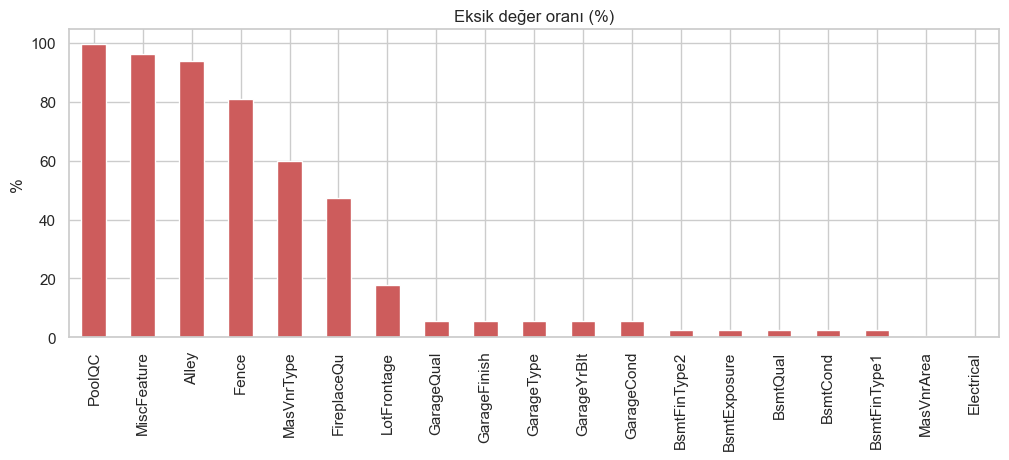

In [3]:
missing = X.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(12, 4))
(missing * 100).plot.bar(ax=ax, color="indianred")
ax.set(title="Eksik değer oranı (%)", ylabel="%");

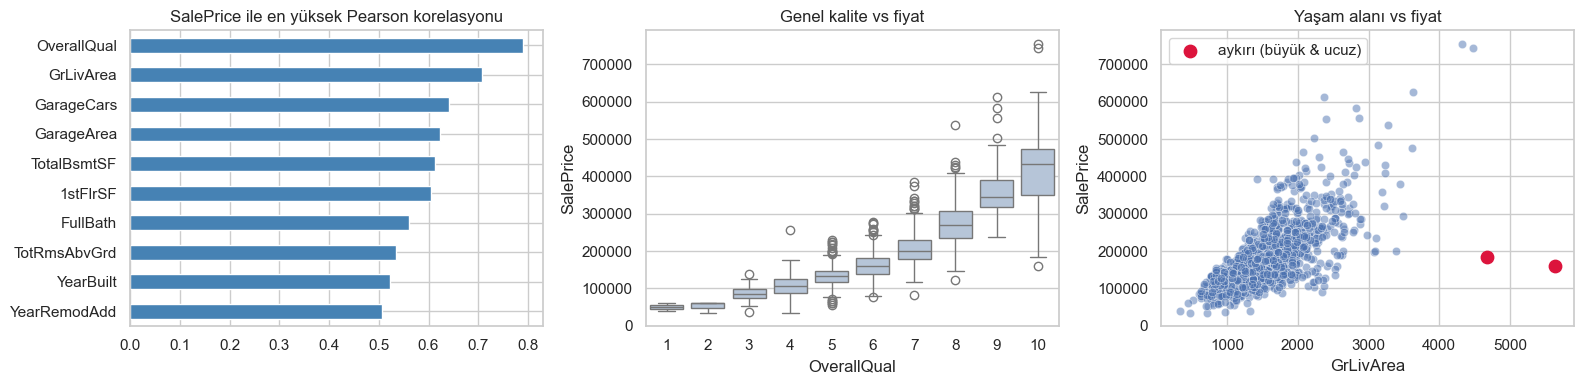

In [4]:
top_corr = data.select_dtypes("number").corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
top_corr.head(10).plot.barh(ax=axes[0], color="steelblue").invert_yaxis()
axes[0].set_title("SalePrice ile en yüksek Pearson korelasyonu")
sns.boxplot(x="OverallQual", y="SalePrice", data=data, ax=axes[1], color="lightsteelblue").set_title("Genel kalite vs fiyat")
sns.scatterplot(x="GrLivArea", y="SalePrice", data=data, ax=axes[2], alpha=.5)
outliers = data[(data.GrLivArea > 4000) & (data.SalePrice < 300_000)]
axes[2].scatter(outliers.GrLivArea, outliers.SalePrice, color="crimson", s=80, label="aykırı (büyük & ucuz)")
axes[2].legend(); axes[2].set_title("Yaşam alanı vs fiyat")
plt.tight_layout()

**Gözlemler**
- `PoolQC`, `MiscFeature`, `Alley`, `Fence` gibi kolonlardaki NaN'lar aslında *"yapı yok"* anlamına geliyor → `"None"` kategorisi olarak ele alınmalı.
- `OverallQual` ve `GrLivArea` fiyatın en güçlü belirleyicileri.
- `GrLivArea > 4000` olup çok ucuz satılan 2 ev (kısmi satış) yazarın da önerdiği gibi aykırı gözlem; final modelde eğitimden çıkarılacak.
- `SalePrice` sağa çarpık → log dönüşümü (bkz. 2.1 d).

# 🐣 1. BASELINE

## 1.1 İlk Özellik Genel Bakış

79 özellik ilk baseline pipeline için tek tek ele alınamayacak kadar fazla! Onları yalnızca `dtype`'larına göre ele alalım:

❓ Kaç sayısal özellik ve kaç kategorik özelliğimiz var?

In [5]:
feat_numerical = X.select_dtypes(include="number").columns
feat_categorical = X.select_dtypes(exclude="number").columns
print(f"{len(feat_numerical)} sayısal özellik, {len(feat_categorical)} kategorik özellik")

36 sayısal özellik, 43 kategorik özellik


❓ Eğitim setimizdeki her kategorik özellik için **benzersiz değer** sayısını içeren `feat_categorical_nunique` adlı bir Series oluşturun. Toplamda kaç benzersiz kategori var?

In [6]:
feat_categorical_nunique = X[feat_categorical].nunique().sort_values()
print("Toplam benzersiz kategori sayısı:", feat_categorical_nunique.sum())
feat_categorical_nunique.tail(10)

Toplam benzersiz kategori sayısı: 251


SaleCondition     6
Functional        7
HouseStyle        8
RoofMatl          8
Condition2        8
SaleType          9
Condition1        9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

🤔 Tüm kategorik özellikleri `OneHotEncode` edersek, özellik matrisimiz `X_preproc` sadece 1400 gözlem için neredeyse 300 (yüksek oranda ilişkili) özellikle oldukça büyük ve seyrek hale gelir. İdeal olarak, modelimize maksimum ~50 özellik beslemeyi hedeflemeliyiz (📚 bu [pratik kuralı](https://datascience.stackexchange.com/a/11480/98300) okuyun)

Ön işleme sonrası kategorik özellik sayısını azaltmak için bildiğimiz 2 ana strateji var:
1. **[Kaldır](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_selection)** modelimize çok az açıklama getiren özellikler; bu özellik öneminin istatistiksel analizi gerektirebilir
2. **[Ordinal kodlama](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)** (one-hot kodlama yerine) kategorik özellikler tamsayılara; ancak bu, düzgün ele alınmazsa zararlı olabilecek bir "sıra" kavramı (1 > 2 > 3 > ...) oluşturur!

❓ Kategorik özellik başına benzersiz değer sayısının **histogramını** çizin. Hızlı kazançlar görüyor musunuz?

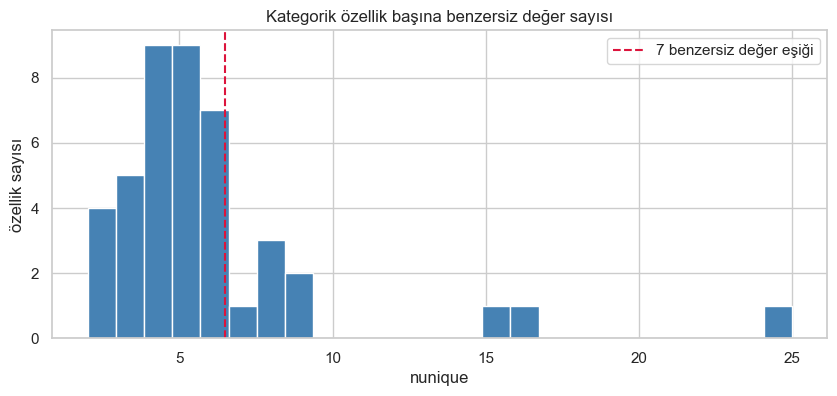

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
feat_categorical_nunique.plot.hist(bins=25, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(6.5, color="crimson", ls="--", label="7 benzersiz değer eşiği")
ax.set(title="Kategorik özellik başına benzersiz değer sayısı", xlabel="nunique", ylabel="özellik sayısı")
ax.legend();

💡 Başlangıç noktası olarak, **7 veya daha fazla benzersiz değeri** olan tüm özellikleri basitçe **kaldırmaya** ve geri kalanını one-hot kodlamaya ne dersiniz? Ordinal kodlama ve istatistiksel özellik seçimini pipeline'ımızın bir sonraki iterasyonu için saklayalım.

❓ OHE yapılacak özelliklerin adlarını aşağıda `feat_categorical_small` adlı listede saklayın. Kaç özellik OHE edilecek?

In [8]:
feat_categorical_small = list(feat_categorical_nunique[feat_categorical_nunique < 7].index)
len(feat_categorical_small)

34

In [9]:
# One-hot kodlama sonrası oluşacak kolon sayısı (ikili özellikler için tek kolon)
n_ohe_columns = sum(n if n > 2 else 1 for n in X[feat_categorical_small].nunique())
print(f"{len(feat_categorical_small)} kategorik özellik OHE edilecek -> ~{n_ohe_columns} kolon")

34 kategorik özellik OHE edilecek -> ~142 kolon


🧪 Kodunuzu aşağıda test edin

In [10]:
try:
    from nbresult import ChallengeResult
except ModuleNotFoundError:  # nbresult sadece bootcamp ortamında kurulu (örn. Kaggle'da yok)
    ChallengeResult = None

if ChallengeResult is not None:
    result = ChallengeResult(
        'features_overview',
        n=len(feat_categorical_small)
    )

    result.write()
    print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.1.1, pluggy-1.5.0 -- C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\MONSTER\OneDrive\Belgeler\Kaggle\S17D2-S-kaggle-competition\tests
plugins: anyio-4.12.1, Faker-24.14.1, asyncio-1.4.0, cov-7.1.0, typeguard-4.6.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 1 item

test_features_overview.py::TestFeaturesOverview::test_feat_categorical_small PASSED [100%]

============================== 1 passed in 1.08s ==============================


💯 You can commit your code:

git add tests/features_overview.pickle

git commit -m 'Completed features_overview step'

git push origin master



## 1.2 Baseline Pipeline

### a) Ön İşleme

❓ Aşağıda açıklanan temel ön işleme pipeline'ını kodlayalım. `preproc_baseline` altında kaydedin.

Kategorik özellikler için:
- En sık değerlerle Simple-Impute
- Başlangıçta 7'den az benzersiz değeri olan özellikleri One-Hot Encode et
- Diğer tüm özellikleri kaldır


Sayısal özellikler için:
- `mean` stratejisiyle Simple-Impute
- Min-Max Scale


<details>
    <summary>ℹ️ Profesyonel ipucu için buraya tıklayın</summary>

Eğer kendinize güveniyorsanız, `Pipeline` veya `ColumnTransformer`'ın daha uzun söz dizimi yerine Sklearn'in daha kısa söz dizimi `make_pipeline` veya `make_column_transformer`'ını deneyebilirsiniz; her adıma manuel olarak isim vermekten kaçınmak istiyorsanız da yararlıdır.
</details>

In [11]:
preproc_numerical_baseline = make_pipeline(
    SimpleImputer(strategy="mean"),
    MinMaxScaler(),
)

preproc_categorical_baseline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
)

preproc_baseline = make_column_transformer(
    (preproc_numerical_baseline, make_column_selector(dtype_include="number")),
    (preproc_categorical_baseline, feat_categorical_small),
    remainder="drop",
)
preproc_baseline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

❓ Ön işlenmiş DataFrame'inizin **şekline** bakın ve `shape_preproc_baseline`'a kaydedin

In [12]:
shape_preproc_baseline = preproc_baseline.fit_transform(X).shape
shape_preproc_baseline

(1460, 178)

🧪 Kodunuzu aşağıda test edin

In [13]:
try:
    from nbresult import ChallengeResult
except ModuleNotFoundError:  # nbresult sadece bootcamp ortamında kurulu (örn. Kaggle'da yok)
    ChallengeResult = None

if ChallengeResult is not None:
    result = ChallengeResult(
        'preproc_baseline',
        shape=shape_preproc_baseline
    )

    result.write()
    print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.1.1, pluggy-1.5.0 -- C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\MONSTER\OneDrive\Belgeler\Kaggle\S17D2-S-kaggle-competition\tests
plugins: anyio-4.12.1, Faker-24.14.1, asyncio-1.4.0, cov-7.1.0, typeguard-4.6.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 1 item

test_preproc_baseline.py::TestPreprocBaseline::test_shape PASSED         [100%]

============================== 1 passed in 0.84s ==============================


💯 You can commit your code:

git add tests/preproc_baseline.pickle

git commit -m 'Completed preproc_baseline step'

git push origin master



### b) Tahminleyici Ekle

❓ `preproc_baseline`'a basit bir Decision Tree modeli ekleyin ve `pipe_baseline` değişkeninde saklayın.

In [14]:
pipe_baseline = make_pipeline(preproc_baseline, DecisionTreeRegressor(random_state=SEED))
pipe_baseline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

### c) Çapraz Doğrulama

❓ Kaggle [yarışma değerlendirme kurallarını](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview/evaluation) okuyun. Hangi performans metriğine ihtiyacınız var? Sklearn'de hazır olarak mevcut mu?

Ne yazık ki değil! Herhangi bir çapraz doğrulama veya Grid Search'e geçmek için özel `sklearn.metrics.scorer` nesnemizi oluşturmamız gerekecek. İşlem aşağıda açıklanmıştır:


1. [`make_scorer`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) kullanarak `scoring` `kwarg` için değer olarak geçirilebilen `rmsle` adlı bir scorer oluşturun:  
    ```python
    cross_val_score(pipe_baseline, X, y, cv=5, scoring=rmsle)
    ```
2. _Maksimize edildiğinde_ en iyi olan negatif karşılığını `rmsle_neg` oluşturun; `GridSearchCV` her zaman bir skoru _maksimize_ etmeye çalıştığı için bu daha sonra işe yarayacak 😉
    ```python
    GridSearchCV(pipe_baseline, param_grid=..., cv=5, scoring=rmsle_neg)
    ```

RMSLE formülü

$$\text{RMSLE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (\log_e (1 + y_i) - \log_e (1 + \hat{y}_i) )^2.}$$

In [15]:
# RMSLE: düşük olan daha iyi -> greater_is_better=False skoru negatif döndürür
def root_mean_squared_log_error(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 0, None)))

rmsle = make_scorer(root_mean_squared_log_error)                               # minimize edilecek
rmsle_neg = make_scorer(root_mean_squared_log_error, greater_is_better=False)  # GridSearchCV için (maksimize)

❓ Baseline performansınıza ilk bakış için bu metriği kullanarak `pipe_baseline`'ınızı 5-kat çapraz doğrulama yapın.    

Ortalama skorunuzu `score_baseline` olarak saklayın

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_baseline = cross_val_score(pipe_baseline, X, y, cv=cv, scoring=rmsle)
score_baseline = cv_baseline.mean()
print(f"Baseline Decision Tree RMSLE: {score_baseline:.4f} ± {cv_baseline.std():.4f}")

Baseline Decision Tree RMSLE: 0.2192 ± 0.0065


### d) Baseline Tahmini

❓ `data` klasöründe sakladığınız Kaggle `test.csv` veri setinden `y_pred_baseline`'ı tahmin edin.

In [17]:
X_test = pd.read_csv(DATA_DIR / "test.csv")
X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])

# Predict y_pred_baseline
pipe_baseline.fit(X, y)
y_pred_baseline = pipe_baseline.predict(X_test)

❓ Son olarak, göndermeye hazır CSV'nizi `data` klasöründe `submission_baseline.csv` olarak saklayın. Kaggle'ın gereken formatını **dikkatli bir şekilde okuyun** ve anlayın ve aşağıda test edin (şimdilik bu baseline'ı Kaggle'a göndermenize gerek yok).

In [18]:
results = pd.concat([X_test_ids, pd.Series(y_pred_baseline, name="SalePrice")], axis=1)
results.head(1)

,Id,SalePrice
0,1461,129000.0


In [19]:
# Export to Kaggle format submission in the `data` folder
results.to_csv(OUTPUT_DIR / "submission_baseline.csv", header=True, index=False)

🧪 Kodunuzu test edin

In [20]:
try:
    from nbresult import ChallengeResult
except ModuleNotFoundError:  # nbresult sadece bootcamp ortamında kurulu (örn. Kaggle'da yok)
    ChallengeResult = None

if ChallengeResult is not None:
    tmp = pd.read_csv(OUTPUT_DIR / "submission_baseline.csv")

    result = ChallengeResult(
        'submission_baseline',
        score_baseline = score_baseline,
        submission_shape = tmp.shape,
        submission_columns = list(tmp.columns),
        submission_dtypes = str(list(tmp.dtypes)),
    )

    result.write()
    print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.1.1, pluggy-1.5.0 -- C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\MONSTER\OneDrive\Belgeler\Kaggle\S17D2-S-kaggle-competition\tests
plugins: anyio-4.12.1, Faker-24.14.1, asyncio-1.4.0, cov-7.1.0, typeguard-4.6.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 4 items

test_submission_baseline.py::TestSubmissionBaseline::test_score_baseline PASSED [ 25%]
test_submission_baseline.py::TestSubmissionBaseline::test_submission_columns PASSED [ 50%]
test_submission_baseline.py::TestSubmissionBaseline::test_submission_dtypes PASSED [ 75%]
test_submission_baseline.py::TestSubmissionBaseline::test_submission_shape PASSED [100%]

============================== 4 passed in 1.94s ==============================


💯 Yo

# 🏋️‍♀️ 2. İTERASYONLAR 

🎉 🎉 Tam pipeline'lı bir baseline model oluşturduğunuz için tebrikler! Şimdi iterasyon yapmanın ve performansı iyileştirmenin ne kadar kolay olduğunu göreceksiniz 🚀

Şimdi amacınız tahmininizi iyileştirmek ve **Recap'ten en az 30 dakika önce** Kaggle'a göndermektir ⏳

Aşağıda iyileştirmeler için bazı önerilerimiz var: **savaşlarınızı seçin** ve pipeline'ınızı uygun gördüğünüz şekilde **aşamalı olarak** iyileştirin!

**Tahminleyiciler**

- Ağaç tabanlı ensemble'lar (bugün mutlaka denenmeli); muhtemelen çok kategorik özelliği olan problemler için en uygun
- Stacking!
- XGBoost!

**Ön İşleme** (ilk ensemble modeliniz çalıştıktan sonra)

- Değerlerinde gizli sıra kavramı olan kategorik özelliklerin **Ordinal Kodlaması** (örn. "kötü", "ortalama", "iyi")
- Gereksiz özellikleri kaldırmak için **İstatistiksel Özellik Seçimi** (aşırı öğrenmeyi önler ve eğitim süresini kısaltır)
- `SalePrice` yerine `log(SalePrice)` tahmin et?
- 🤷

## 2.1 Ön İşleme İterasyonu ♲ 
**⚠️ Bölüm 2.2'de tahminleyicilerinizde iterasyon yaptıktan sonra buraya geri dönün ⚠️**

⏩ Kullanımda değilsem beni daralt!

### a) Ordinal Kodlama (~1s)

❓ Aşağıdaki özelliğe bakın. Akıllıca bir şekilde sayısal olarak kodlanamaz mı?
```
ExterQual: Dıştaki malzemenin kalitesini değerlendirir
		
       Ex	Mükemmel
       Gd	İyi
       TA	Ortalama/Tipik
       Fa	Adil
       Po	Zayıf
```

💡 Neyse ki, `OrdinalEncoder` ve `categories` argümanı tam da bunu yapmamıza izin veriyor! Aşağıda kontrol edin ve bunun nasıl çalıştığını anladığınızdan emin olun 👇

In [21]:
# Define specific order for features
# Note: if you change this order, it will change the output for .transform()
feature_A_sorted_values = ['bad', 'average', 'good']
feature_B_sorted_values = ['dirty', 'clean', 'new']

encoder = OrdinalEncoder(
    categories=[
        feature_A_sorted_values,
        feature_B_sorted_values
    ],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Just some random training data
XX = [
    ['good', 'dirty'],
    ['bad', 'new'],
    ['average', 'clean'],
]

encoder.fit(XX)

encoder.transform([
        ['bad', "dirty"],
        ["average", "clean"],
        ['good', 'new'],
        ['bad', 'oops never seen this label before']
])

array([[ 0.,  0.],
       [ 1.,  1.],
       [ 2.,  2.],
       [ 0., -1.]])

❓ **Sıra sizde**: kategorik ön işleyicinizi şunlara bölün

- **Bazı özellikleri** (seçiminize göre) ordinal kodlamak için `preproc_ordinal`
- Diğerlerini one-hot kodlamak için `preproc_nominal`


<details>
    <summary>İpuçları</summary>

- Özelliklerin adlarını ve sıralı değerlerini sabit kodlamaktan kaçınamayacaksınız! Düzenli olun!
- Kötü sürprizlerden kaçınmak için özelliklerinizi alfabetik olarak sıralamanız iyi bir uygulamadır
</details>

In [22]:
# Tanımlama dosyasına (data_description.txt) göre sıralı anlamı olan kategorik özellikler
# "None" = ilgili yapı yok (örn. bodrum yok); NaN'ları bu seviyeye impute ediyoruz
quality = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
ORDINAL_CATEGORIES = {
    "BsmtCond": quality,
    "BsmtExposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtQual": quality,
    "CentralAir": ["N", "Y"],
    "ExterCond": quality,
    "ExterQual": quality,
    "Fence": ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "FireplaceQu": quality,
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "GarageCond": quality,
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "GarageQual": quality,
    "HeatingQC": quality,
    "KitchenQual": quality,
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": quality,
}
feat_ordinal = sorted(ORDINAL_CATEGORIES)  # alfabetik sıra -> categories ile birebir eşleşme
feat_nominal = sorted(set(feat_categorical) - set(feat_ordinal))

preproc_ordinal = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="None"),
    OrdinalEncoder(
        categories=[ORDINAL_CATEGORIES[f] for f in feat_ordinal],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    ),
    MinMaxScaler(),
)

preproc_nominal = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="None"),
    OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False),
)

preproc_numerical = make_pipeline(
    SimpleImputer(strategy="median"),
    MinMaxScaler(),
)

preproc = make_column_transformer(
    (preproc_numerical, make_column_selector(dtype_include="number")),
    (preproc_ordinal, feat_ordinal),
    (preproc_nominal, feat_nominal),
)

# Karşılaştırmaları adil yapmak için aynı doğrusal model + log hedef dönüşümü (bkz. 2.1 d)
def log_target(estimator):
    return TransformedTargetRegressor(estimator, func=np.log1p, inverse_func=np.expm1)

def evaluate(pipe, name, X_=X, y_=y):
    t0 = time.time()
    scores = cross_val_score(pipe, X_, y_, cv=cv, scoring=rmsle, n_jobs=-1)
    print(f"{name:<45} RMSLE = {scores.mean():.4f} ± {scores.std():.4f}  ({time.time() - t0:.1f}s)")
    return scores.mean()

print("Ön işleme sonrası şekil:", preproc.fit_transform(X).shape)
_ = evaluate(log_target(make_pipeline(preproc_baseline, Ridge())), "Baseline preproc + Ridge")
_ = evaluate(log_target(make_pipeline(preproc, Ridge())), "Ordinal + nominal preproc + Ridge")

Ön işleme sonrası şekil: (1460, 189)


Baseline preproc + Ridge                      RMSLE = 0.1596 ± 0.0404  (27.6s)


Ordinal + nominal preproc + Ridge             RMSLE = 0.1452 ± 0.0335  (23.5s)


### b) İstatistiksel Özellik Seçimi (~30dk)

Amacımız aşırı öğrenmeyi sınırlamak ve eğitim süresini kısaltmak için en az ilginç özellikleri kaldırmaktır.  

🔥 Pipeline'ınızda doğrudan Sklearn'in [feature selection](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_selection) dönüştürücülerini kullanacağız!

❗️ Başlamak için bugün **sadece Seçenek 1'i** denemenizi öneriyoruz. Seçenek 2 ve 3 Recap'te düzeltilecek!

#### Seçenek 1 (Önerilen) - <font color=green>Tek değişkenli</font> Özellik Seçimi
*hedef `y` ile karşılıklı bilgilerine dayalı*

- `preproc` pipeline'ınızın sonuna bir `SelectPercentile` filtresi eklemeyi tereddüt etmeyin.
- Bu, tek tek alındığında hedefimizi en az açıklayan özellikleri filtreleyecek!
- SelectPercentile'a geçirmenizi önerdiğimiz istatistiksel test `mutual_info_regression`

<details>
    <summary markdown='span'>🤔 Karşılıklı bilgi nedir? Buraya tıklayın!</summary>

- [Karşılıklı Bilgi](https://en.wikipedia.org/wiki/Mutual_information) iki olasılık dağılımı arasındaki **istatistiksel** mesafedir
- Korelasyon iki rastgele değişken arasındaki **doğrusal** mesafedir
- Karşılıklı Bilgi daha geneldir ve X'i gözlemledikten sonra Y'deki belirsizliğin azalmasını ölçer.
- Öte yandan, zaten düzgün değişkenlerle (sürekli sayısal değişkenler gibi) çalıştığınızı biliyorsanız, bazen korelasyon onlar hakkında daha fazla bilgi verebilir, örneğin ilişkileri monoton ise.

[Bu animasyona](https://twitter.com/ari_seff/status/1409296508634152964) bakın
</details>

In [23]:
preproc_selected = make_pipeline(
    preproc,
    SelectPercentile(score_func=lambda X_, y_: mutual_info_regression(X_, y_, random_state=SEED), percentile=75),
)
_ = evaluate(log_target(make_pipeline(preproc_selected, Ridge())), "preproc + SelectPercentile(MI, 75%) + Ridge")

preproc + SelectPercentile(MI, 75%) + Ridge   RMSLE = 0.1439 ± 0.0327  (26.3s)


#### Seçenek 2 - <font color=green>Çok değişkenli</font> Özellik Seçimi
*hedef `y` ile birleşik ilişkilerine dayalı*

🤔 Diğerleriyle birleştirildiğinde bile hedefimizi tahmin etmeye yardımcı olmayan özellikleri kaldırmak istiyoruz.

1️⃣ Bunu yapmak için, bir tahminleyici ile birlikte [`permutation_importance`](https://scikit-learn.org/stable/modules/permutation_importance.html) metriğini kullanabileceğimizi unutmayın! Her özellik için bir pipeline eğitir ve hangi özelliğin rastgele karıştırıldığında performans skorumuzu en çok *düşürdüğünü* tahmin eder. Bunlar kaldırmak istemediğimiz en önemli özelliklerimiz olacaktır.

En iyi şey, `scikit-learn`'in bu metodolojiyi [`SequentialFeatureSelector`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html) dönüştürücüsü sayesinde doğrudan `preproc` pipeline'ınıza entegre etmenize izin vermesidir; bu, `cross_val_score`'a göre en az önemli özellikleri özyinelemeli olarak kaldıracaktır.

Ancak çok özelliğiniz olduğunda, bu işlem eğitilmesi son derece uzun sürebilir.

2️⃣ Alternatif olarak, daha hızlı bir yol, fit edildiğinde zaten bazı `feature_importance` ölçüleri çıkaran modelleri kullanmak olacaktır. Örneğin, Gini tabanlı `feature_importance_` ile ağaçlar veya L1 `coef_` ile Lasso regresyonları. `scikit-learn` zaten tam da bunu yapmak için [`SelectFromModel`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html) dönüştürücüsüne sahiptir.

In [24]:
# L1 (Lasso) katsayıları sıfır olan özellikleri eleyen çok değişkenli seçim
preproc_l1 = make_pipeline(preproc, SelectFromModel(Lasso(alpha=5e-4, max_iter=50_000)))
_ = evaluate(log_target(make_pipeline(preproc_l1, Ridge())), "preproc + SelectFromModel(Lasso) + Ridge")

n_kept = preproc_l1.fit(X, np.log1p(y))[-1].get_support().sum()
print(f"Lasso {preproc.fit_transform(X).shape[1]} özellikten {n_kept} tanesini tuttu")

preproc + SelectFromModel(Lasso) + Ridge      RMSLE = 0.1448 ± 0.0309  (11.3s)


Lasso 189 özellikten 86 tanesini tuttu


#### Seçenek 3 - <font color=green>Denetimsiz</font> Seçim?
*sadece `X`'in özelliklerine dayalı filtre*

❓ Hızlı bir kazanç, en düşük varyansa sahip özellikleri kaldırmaktır. Düşünün: sadece bir değeri olan bir özellik yararsızdır (ve 0 varyansa sahiptir).

Pipeline'ınızın sonuna bir [`VarianceThreshold`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html) eklemeyi tereddüt etmeyin!

In [25]:
preproc_var = make_pipeline(preproc, VarianceThreshold(threshold=0.001))
n_before = preproc.fit_transform(X).shape[1]
n_after = preproc_var.fit_transform(X).shape[1]
print(f"VarianceThreshold: {n_before} -> {n_after} özellik")
_ = evaluate(log_target(make_pipeline(preproc_var, Ridge())), "preproc + VarianceThreshold + Ridge")

VarianceThreshold: 189 -> 187 özellik


preproc + VarianceThreshold + Ridge           RMSLE = 0.1453 ± 0.0335  (0.6s)


❓ Ek olarak, sadece **sayısal özelliklerimiz** arasındaki korelasyonu kontrol edebiliriz

- Herhangi bir **sayısal** özelliğin diğerleriyle neredeyse tamamen korelasyonlu olup olmadığını görsel olarak kontrol etmek için [Pearson korelasyonu](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) ile birlikte bir ısı haritası kullanın
- En yüksek çok doğrusal bağlantıya sahip özellikleri kontrol etmek için `statsmodels`'den `VIF` kullanın

,,|pearson|
GarageCars,GarageArea,0.882475
YearBuilt,GarageYrBlt,0.825667
GrLivArea,TotRmsAbvGrd,0.825489
TotalBsmtSF,1stFlrSF,0.819530
2ndFlrSF,GrLivArea,0.687501
BedroomAbvGr,TotRmsAbvGrd,0.676620
BsmtFinSF1,BsmtFullBath,0.649212
YearRemodAdd,GarageYrBlt,0.642277


C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The mod

C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The mod

C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The mod

C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The mod

C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The mod

C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The mod

C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


BsmtFinSF1      1.000800e+15
BsmtFinSF2      1.000800e+15
BsmtUnfSF       1.000800e+15
TotalBsmtSF     1.000800e+15
GrLivArea       1.000800e+15
LowQualFinSF    1.000800e+15
2ndFlrSF        1.000800e+15
1stFlrSF        1.000800e+15
GarageCars      5.584096e+00
GarageArea      5.459691e+00
Name: VIF, dtype: float64

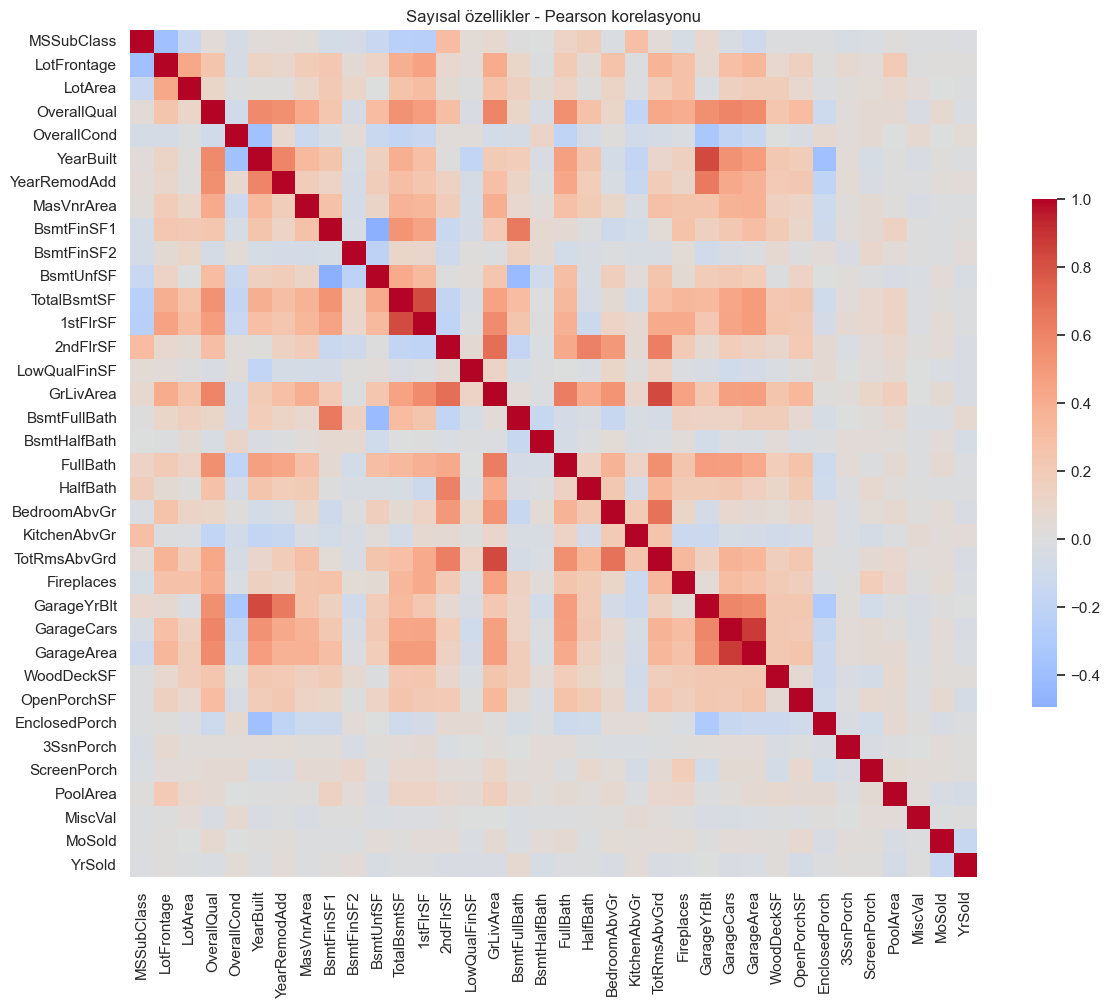

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr_num = X[feat_numerical].corr(method="pearson")
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_num, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .6}, ax=ax)
ax.set_title("Sayısal özellikler - Pearson korelasyonu");

# En yüksek korelasyonlu çiftler
pairs = (corr_num.where(np.triu(np.ones(corr_num.shape, dtype=bool), k=1))
         .stack().abs().sort_values(ascending=False))
display(pairs.head(8).to_frame("|pearson|"))

# VIF (çoklu doğrusal bağlantı) - medyanla doldurulmuş sayısal özellikler
X_num = X[feat_numerical].fillna(X[feat_numerical].median())
X_num = (X_num - X_num.mean()) / X_num.std()
vif = pd.Series([variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])],
                index=feat_numerical, name="VIF").sort_values(ascending=False)
vif.head(10)

❓ **Ordinal özellikler** için, bazı **ordinal kodlanmış** özelliklerin diğerleriyle neredeyse tamamen benzer şekilde "sıralanıp" sıralanmadığını kontrol etmek için bunun yerine [Spearman rank korelasyonu](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) kullanabiliriz. Tekrar bir ısı haritası çizmekten çekinmeyin.

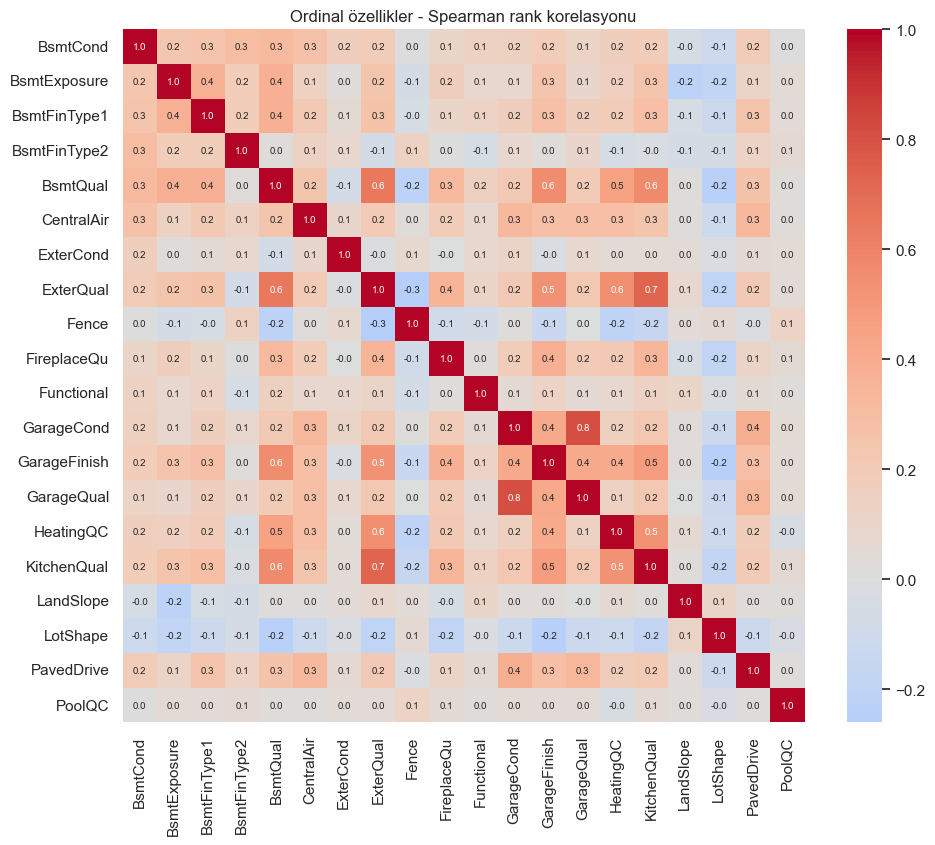

In [27]:
X_ord = pd.DataFrame(preproc_ordinal.fit_transform(X[feat_ordinal]), columns=feat_ordinal)
corr_ord = X_ord.corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_ord, cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Ordinal özellikler - Spearman rank korelasyonu");

❓ Şimdi, belirli bir (Spearman + Pearson) korelasyon eşiğinin ötesinde istediğiniz herhangi bir özelliği kaldıran pipeline'ınızda bir "filtre" oluşturmaktan çekinmeyin; özel bir dönüştürücü sınıfa ihtiyacınız olacak.

In [28]:
class CorrelationDropper(BaseEstimator, TransformerMixin):
    """fit sırasında |Spearman korelasyonu| > threshold olan çiftlerden ikincisini kaldırır."""

    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr = pd.DataFrame(X).corr(method="spearman").abs().fillna(0).values
        upper = np.triu(corr, k=1)
        self.to_drop_ = np.where((upper > self.threshold).any(axis=0))[0]
        self.support_ = np.setdiff1d(np.arange(corr.shape[1]), self.to_drop_)
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.support_]

preproc_corr = make_pipeline(preproc, CorrelationDropper(threshold=0.95))
print("Kaldırılan özellik sayısı:", len(preproc_corr.fit(X)[-1].to_drop_))
_ = evaluate(log_target(make_pipeline(preproc_corr, Ridge())), "preproc + CorrelationDropper(0.95) + Ridge")

Kaldırılan özellik sayısı: 10


preproc + CorrelationDropper(0.95) + Ridge    RMSLE = 0.1450 ± 0.0339  (3.1s)


### c) Döngüsel Özellikleri İşle

❓ Zaman tabanlı özelliklerimiz var, neden onları döngüsel özelliklere **dönüştürmüyoruz**?

🔎 Bunu neden ve nasıl yaptığımız hakkında daha fazla bilgi edinmek istiyorsanız, `Prepare the dataset` ünitesinin `Preprocessing Workflow` yarışmasına geri dönün.

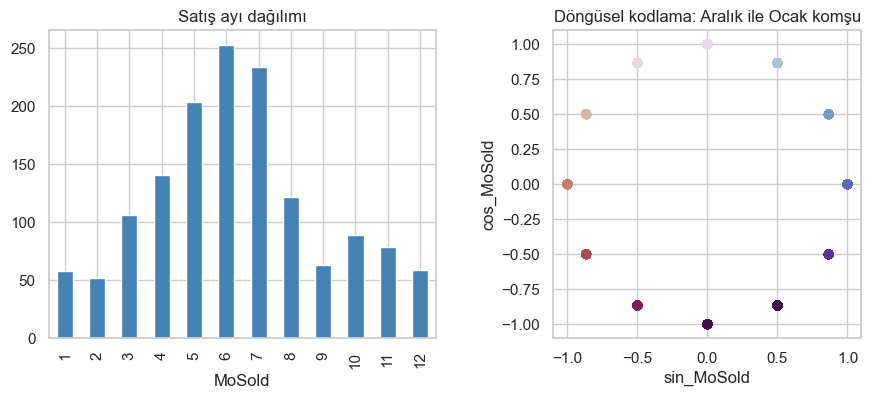

In [29]:
months_in_a_year = 12
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
X["MoSold"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue", title="Satış ayı dağılımı")
sin_m = np.sin(2 * np.pi * (X["MoSold"] - 1) / months_in_a_year)
cos_m = np.cos(2 * np.pi * (X["MoSold"] - 1) / months_in_a_year)
axes[1].scatter(sin_m, cos_m, c=X["MoSold"], cmap="twilight")
axes[1].set(title="Döngüsel kodlama: Aralık ile Ocak komşu", xlabel="sin_MoSold", ylabel="cos_MoSold", aspect="equal");

# Dönüşümü 2.2'deki feature_engineering() fonksiyonuna taşıyoruz: böylece train ve test'e
# aynı şekilde uygulanır ve X global olarak değiştirilmez (idempotent notebook).

### d) Hedef Mühendisliği (~15dk)

❓ RMS**L**E'yi minimize etmemiz isteniyor. Hedefimizin `log`'unu doğrudan tahmin etmek için neden dönüştürmüyoruz?
- `y` hedefinin histogramını kontrol edin
- Normal dağılımlı değişkenlerin doğrusal veya parametrik modellerle tahmin edilmesi daha kolay olmalıdır
- `y_log` ve yeni performans metriklerinizi oluşturun
- Sonunda tahminlerinizin üssünü almayı unutmayın!

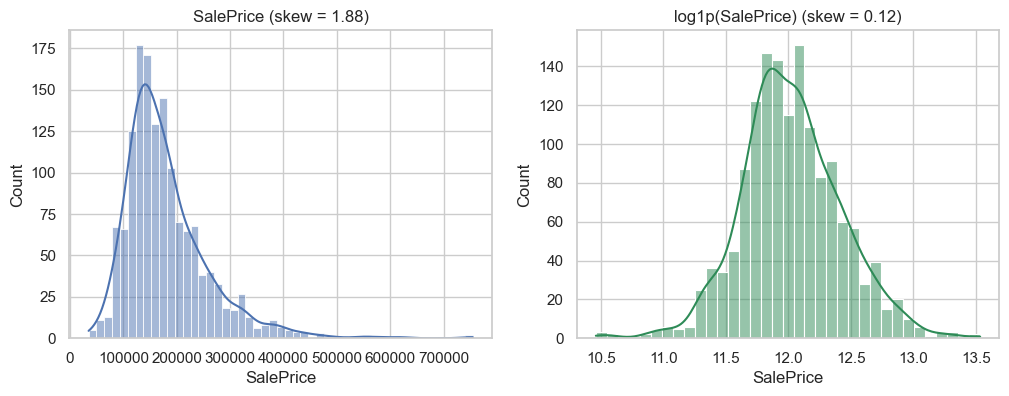

Ridge - ham hedef RMSLE: 0.1855 | log hedef RMSLE: 0.1452


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, kde=True, ax=axes[0]).set(title=f"SalePrice (skew = {y.skew():.2f})")
sns.histplot(np.log1p(y), kde=True, ax=axes[1], color="seagreen").set(title=f"log1p(SalePrice) (skew = {np.log1p(y).skew():.2f})")
plt.show()

y_log = np.log1p(y)

# log1p uzayında RMSE == orijinal uzayda RMSLE (tam olarak Kaggle metriği)
rmse = make_scorer(root_mean_squared_error)
rmse_neg = make_scorer(root_mean_squared_error, greater_is_better=False)

pipe_ridge = make_pipeline(preproc, Ridge())
s_raw = cross_val_score(pipe_ridge, X, y, cv=cv, scoring=rmsle).mean()
s_log = cross_val_score(pipe_ridge, X, y_log, cv=cv, scoring=rmse).mean()
print(f"Ridge - ham hedef RMSLE: {s_raw:.4f} | log hedef RMSLE: {s_log:.4f}")

## 2.2 Model İterasyonu ♻

#### a) Ön İşleme Pipeline'ının Son Versiyonu
❓ Aşağıda ön işleme pipeline'ınızın yeni bir tanımıyla başlamanızı tavsiye ediyoruz. Yukarıdaki mevcut kodunuzdan kopyala-yapıştır yapın.

Bu şekilde gerektiğinde hızlıca güncelleyebilir ve ardından mümkün olan en iyi modeli bulmak için birçok model türü deneyebilirsiniz. GridSearch deneyebilirsiniz (bu çok zaman alabilir) veya model model gidebilirsiniz.

Önceki ünitelerde ve bugün öğrendiğiniz farklı modellerden bir veya daha fazlasını deneyebilirsiniz. 

👉 Hedefleriniz:

  - **En az bir doğrusal model deneyin**
  
  - **Bu ünitede keşfettiğiniz ağaç tabanlı modellerden en az birini deneyin**.

  - Farklı modellerinizin **çapraz doğrulama** skorlarını karşılaştırın.

  - Farklı modellerin çapraz doğrulanmasının **ne kadar sürdüğünü karşılaştırmak** da ilginçtir. 🔎 Bir notebook hücresinin yürütülmesini zamanlamak için hücrenin ilk satırına `%%time` sihirli komutunu ekleyin.

In [31]:
OUTLIER_MASK = (X["GrLivArea"] > 4000) & (y < 300_000)
print("Kaldırılan aykırı gözlem Id'leri:", list(X.index[OUTLIER_MASK]))

NONE_MEANS_ABSENT = ["Alley", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "BsmtQual",
                     "Fence", "FireplaceQu", "GarageCond", "GarageFinish", "GarageQual", "GarageType",
                     "MasVnrType", "MiscFeature", "PoolQC"]
ZERO_MEANS_ABSENT = ["BsmtFinSF1", "BsmtFinSF2", "BsmtFullBath", "BsmtHalfBath", "BsmtUnfSF",
                     "GarageArea", "GarageCars", "MasVnrArea", "TotalBsmtSF"]


def feature_engineering(df):
    """Domain bilgisine dayalı, satır bazlı (veri sızıntısı olmayan) dönüşümler."""
    df = df.copy()
    df["MSSubClass"] = df["MSSubClass"].astype(str)          # sayısal görünümlü ama nominal
    df[NONE_MEANS_ABSENT] = df[NONE_MEANS_ABSENT].fillna("None")
    df[ZERO_MEANS_ABSENT] = df[ZERO_MEANS_ABSENT].fillna(0)

    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    df["TotalPorchSF"] = df[["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]].sum(axis=1)
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
    df["QualLivArea"] = df["OverallQual"] * df["GrLivArea"]
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)

    df["sin_MoSold"] = np.sin(2 * np.pi * (df["MoSold"] - 1) / months_in_a_year)
    df["cos_MoSold"] = np.cos(2 * np.pi * (df["MoSold"] - 1) / months_in_a_year)
    # Neredeyse sabit / bilgi taşımayan kolonlar
    return df.drop(columns=["MoSold", "Utilities", "Street", "PoolQC"])


X_fe = feature_engineering(X[~OUTLIER_MASK])
y_fe_log = np.log1p(y[~OUTLIER_MASK])

feat_ordinal_fe = [f for f in feat_ordinal if f in X_fe.columns]
feat_nominal_fe = sorted(set(X_fe.select_dtypes(exclude="number").columns) - set(feat_ordinal_fe))
feat_numerical_fe = list(X_fe.select_dtypes(include="number").columns)
feat_skewed = [f for f in feat_numerical_fe if X_fe[f].min() >= 0 and abs(X_fe[f].skew()) > 0.75]


def make_preproc_final():
    return make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median"),
                       FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                       RobustScaler()), feat_skewed),
        (make_pipeline(SimpleImputer(strategy="median"), RobustScaler()),
         [f for f in feat_numerical_fe if f not in feat_skewed]),
        (make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                       OrdinalEncoder(categories=[ORDINAL_CATEGORIES[f] for f in feat_ordinal_fe],
                                      handle_unknown="use_encoded_value", unknown_value=-1)), feat_ordinal_fe),
        (make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                       OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)), feat_nominal_fe),
        verbose_feature_names_out=False,
    )


preproc_final = make_preproc_final()
print("X_fe:", X_fe.shape, "-> ön işleme sonrası:", preproc_final.fit_transform(X_fe).shape,
      f"| {len(feat_skewed)} çarpık özelliğe log1p uygulandı")
preproc_final

Kaldırılan aykırı gözlem Id'leri: [524, 1299]
X_fe: (1458, 86) -> ön işleme sonrası: (1458, 208) | 23 çarpık özelliğe log1p uygulandı


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

#### b) Model Karşılaştırması

Tüm modeller **log1p(SalePrice)** üzerinde eğitilir; bu uzaydaki RMSE doğrudan Kaggle metriği olan RMSLE'ye eşittir. Her model için 5-kat **out-of-fold (OOF)** tahminler üretip hem skor hem süre karşılaştırıyoruz. Bu OOF tahminler bir sonraki adımda blend ağırlıklarını öğrenmek için kullanılacak.

- **Doğrusal:** Ridge, Lasso, ElasticNet (one-hot + log-çarpık özelliklerle çok güçlü)
- **Kernel:** SVR (RBF)
- **Ağaç tabanlı ensemble:** Gradient Boosting, XGBoost, LightGBM, CatBoost

> Not: Hiperparametreler önceden küçük aramalarla belirlendi; notebook'un hızlı çalışması için burada sabit tutuluyor.

In [32]:
MODELS = {
    "Ridge": RidgeCV(alphas=np.logspace(-1, 2.5, 30)),
    "Lasso": LassoCV(alphas=np.logspace(-4.5, -2, 30), max_iter=50_000),
    "ElasticNet": ElasticNetCV(l1_ratio=[.3, .6, .9], alphas=np.logspace(-4.5, -2, 20), max_iter=50_000),
    "SVR": SVR(C=20, epsilon=0.008, gamma=0.0003),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=3000, learning_rate=0.02, max_depth=4, max_features="sqrt",
                                                  min_samples_leaf=15, loss="huber", subsample=0.8, random_state=SEED),
    "XGBoost": XGBRegressor(n_estimators=3000, learning_rate=0.02, max_depth=3, subsample=0.7, colsample_bytree=0.5,
                            reg_alpha=0.005, min_child_weight=2, random_state=SEED, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=4000, learning_rate=0.01, num_leaves=6, max_bin=200, subsample=0.75,
                              subsample_freq=5, colsample_bytree=0.25, min_child_samples=10, random_state=SEED, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=5, l2_leaf_reg=3, random_seed=SEED,
                                  verbose=0, allow_writing_files=False),
}

cv_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof = pd.DataFrame(index=X_fe.index)
leaderboard = []
for name, model in MODELS.items():
    t0 = time.time()
    pipe = make_pipeline(make_preproc_final(), clone(model))
    # Kendi thread'lerini yöneten boosting kütüphaneleri sıralı, diğerleri paralel
    n_jobs = 1 if name in {"XGBoost", "LightGBM", "CatBoost"} else -1
    oof[name] = cross_val_predict(pipe, X_fe, y_fe_log, cv=cv_final, n_jobs=n_jobs)
    fold_scores = [root_mean_squared_error(y_fe_log.iloc[te], oof[name].iloc[te]) for _, te in cv_final.split(X_fe)]
    leaderboard.append({"model": name, "cv_rmsle": np.mean(fold_scores), "std": np.std(fold_scores),
                        "time_s": time.time() - t0})
    print(f"{name:<18} RMSLE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}  ({time.time() - t0:.0f}s)")

leaderboard = pd.DataFrame(leaderboard).set_index("model").sort_values("cv_rmsle")
leaderboard

Ridge              RMSLE = 0.1126 ± 0.0079  (2s)


Lasso              RMSLE = 0.1117 ± 0.0069  (6s)


ElasticNet         RMSLE = 0.1116 ± 0.0069  (10s)


SVR                RMSLE = 0.1103 ± 0.0094  (1s)


GradientBoosting   RMSLE = 0.1134 ± 0.0089  (41s)


XGBoost            RMSLE = 0.1104 ± 0.0064  (55s)


Exception in thread Thread-10 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa7 in position 1: invalid start byte


  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\MONSTER\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

LightGBM           RMSLE = 0.1148 ± 0.0084  (68s)


CatBoost           RMSLE = 0.1120 ± 0.0066  (122s)


,cv_rmsle,std,time_s
model,,,
SVR,0.110281,0.009444,1.383255
XGBoost,0.110438,0.006410,55.144265
ElasticNet,0.111589,0.006929,10.123511
Lasso,0.111651,0.006947,5.912220
CatBoost,0.112027,0.006631,121.917829
Ridge,0.112649,0.007884,2.097703
GradientBoosting,0.113350,0.008870,40.687360
LightGBM,0.114788,0.008431,67.797846


#### c) Ensemble: Ağırlıklı Blend

Farklı model aileleri farklı hatalar yapar (aşağıdaki OOF korelasyon matrisine bakın). Ağırlıkları, OOF tahminler üzerinde **negatif olmayan en küçük kareler (NNLS)** ile öğreniyoruz ve toplamı 1 olacak şekilde normalize ediyoruz. Ağırlıklar OOF üzerinde öğrenildiği için skor hafif iyimser olabilir; bu yüzden basit ortalamayı da referans olarak raporluyoruz.

En iyi tek model (SVR): 0.1103
Basit ortalama blend:              0.1074
NNLS ağırlıklı blend:              0.1062
Baseline Decision Tree:            0.2192


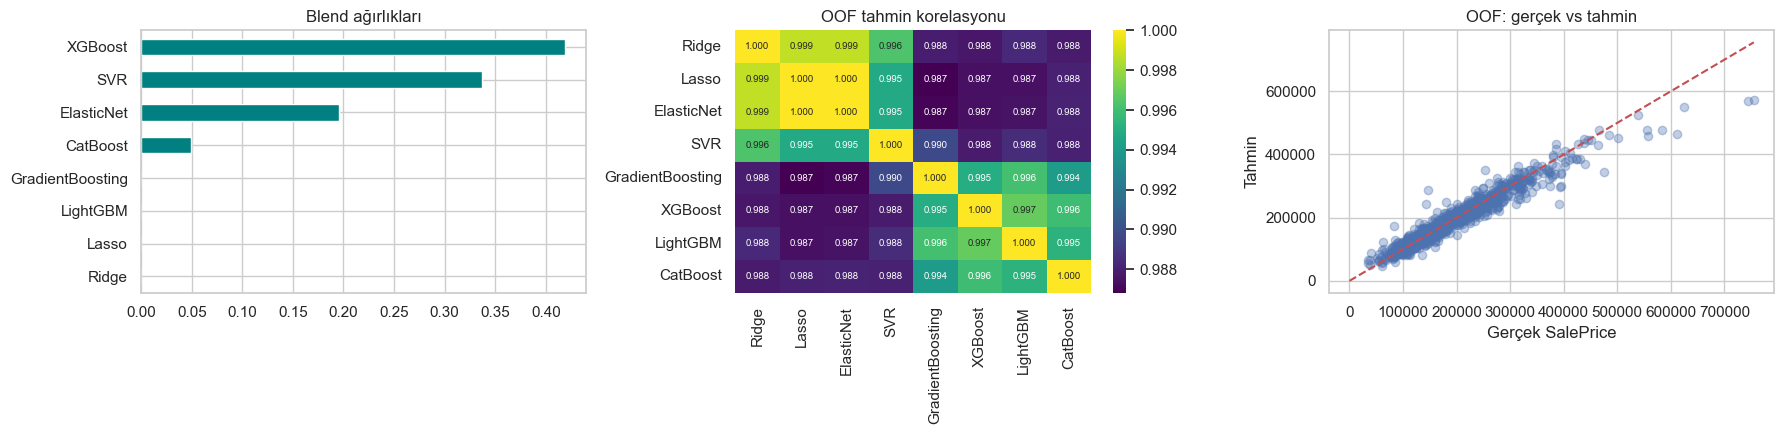

In [33]:
weights, _ = nnls(oof.values, y_fe_log.values)
blend_weights = pd.Series(weights / weights.sum(), index=oof.columns).round(4)

blend_oof = oof.values @ blend_weights.values
score_blend = root_mean_squared_error(y_fe_log, blend_oof)
score_mean = root_mean_squared_error(y_fe_log, oof.mean(axis=1))

print(f"En iyi tek model ({leaderboard.index[0]}): {leaderboard.cv_rmsle.iloc[0]:.4f}")
print(f"Basit ortalama blend:              {score_mean:.4f}")
print(f"NNLS ağırlıklı blend:              {score_blend:.4f}")
print(f"Baseline Decision Tree:            {score_baseline:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
blend_weights.sort_values().plot.barh(ax=axes[0], color="teal", title="Blend ağırlıkları")
sns.heatmap(oof.corr(), annot=True, fmt=".3f", cmap="viridis", ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("OOF tahmin korelasyonu")
axes[2].scatter(np.expm1(y_fe_log), np.expm1(blend_oof), alpha=.35)
lim = [0, np.expm1(y_fe_log).max()]
axes[2].plot(lim, lim, "r--")
axes[2].set(title="OOF: gerçek vs tahmin", xlabel="Gerçek SalePrice", ylabel="Tahmin")
plt.tight_layout()

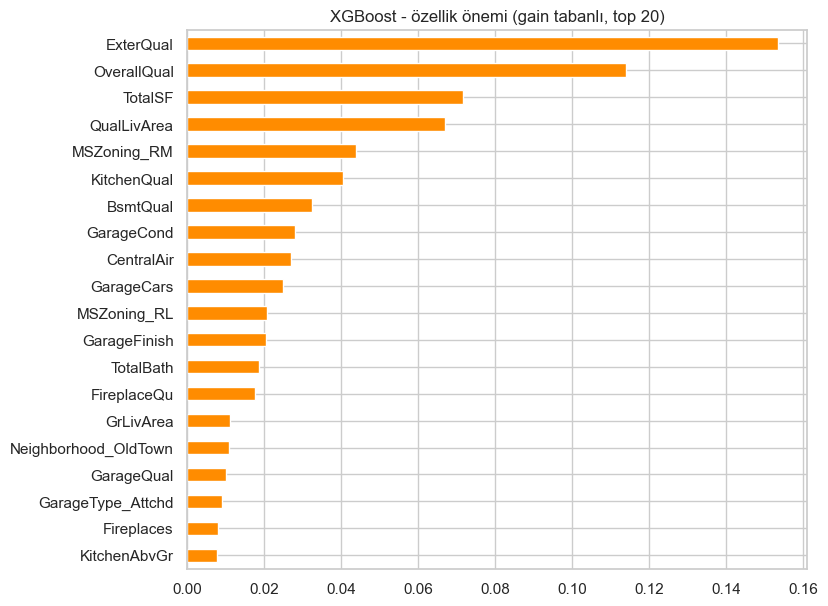

In [34]:
# Yorumlanabilirlik: XGBoost'un en önemli 20 özelliği
xgb_pipe = make_pipeline(make_preproc_final(), clone(MODELS["XGBoost"])).fit(X_fe, y_fe_log)
importances = pd.Series(xgb_pipe[-1].feature_importances_, index=xgb_pipe[0].get_feature_names_out())
importances.nlargest(20).sort_values().plot.barh(figsize=(8, 7), color="darkorange",
                                                 title="XGBoost - özellik önemi (gain tabanlı, top 20)");

# 🏅GÖNDERİM 

Kaggle'a göndererek gerçek test skorunuzu keşfetme zamanı! 

👉 Modelinizin ne kadar iyi olduğunu görmek için sonraki adımları takip edin ve tamamlayın!

In [35]:
X_test = pd.read_csv(DATA_DIR / "test.csv")

X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])

2.1'deki isteğe bağlı döngüsel özellik işlemini çalıştırdıysanız, X_test'i pipeline'ınıza beslemeden önce ekstra sütunları eklemek için aşağıdaki hücreyi çalıştırmanız gerekecek.

In [36]:
# Döngüsel özellikler dahil tüm özellik mühendisliği train ile aynı fonksiyonla uygulanır
X_test_fe = feature_engineering(X_test)
assert list(X_test_fe.columns) == list(X_fe.columns)
X_test_fe.shape

(1459, 86)

👉 En iyi tahminleyicinizi kullanarak tahmin yapın ve sonuçları `predictions`'da saklayın.

In [37]:
final_pipes = {name: make_pipeline(make_preproc_final(), clone(model)).fit(X_fe, y_fe_log)
               for name, model in MODELS.items() if blend_weights[name] > 0}

test_preds_log = pd.DataFrame({name: pipe.predict(X_test_fe) for name, pipe in final_pipes.items()})
predictions = np.expm1(sum(blend_weights[name] * test_preds_log[name] for name in final_pipes))

display(test_preds_log.corr().round(3))
pd.Series(predictions).describe()

,ElasticNet,SVR,XGBoost,CatBoost
ElasticNet,1.000,0.995,0.988,0.990
SVR,0.995,1.000,0.987,0.989
XGBoost,0.988,0.987,1.000,0.997
CatBoost,0.990,0.989,0.997,1.000


count      1459.000000
mean     178529.105246
std       78336.241242
min       43836.957311
25%      127091.117081
50%      157368.344865
75%      210611.674508
max      832668.902876
dtype: float64

👉 Tahminlerinizi Kaggle'a göndermek için hazırlamak üzere aşağıdaki hücreleri çalıştırın.

In [38]:
# Create a DataFrame in the correct format
results = pd.concat([X_test_ids, pd.Series(predictions, name="SalePrice")], axis=1)
results

,Id,SalePrice
0,1461,121414.882244
1,1462,162286.205203
2,1463,185311.701343
3,1464,196348.472910
4,1465,188501.460319
...,...,...
1454,2915,86613.074141
1455,2916,79881.101578
1456,2917,168601.825613
1457,2918,119504.389197


In [39]:
# Export to Kaggle format submission
results.to_csv(OUTPUT_DIR / "submission_final.csv", header=True, index=False)
if Path("/kaggle/working").exists():
    results.to_csv(OUTPUT_DIR / "submission.csv", header=True, index=False)  # Kaggle "Submit" butonu için
print("Kaydedildi:", OUTPUT_DIR / "submission_final.csv", results.shape)

Kaydedildi: data\submission_final.csv (1459, 2)


# 📌 Sonuç

| Aşama | CV RMSLE (5-kat) |
|---|---|
| Baseline — Decision Tree (34 OHE + sayısal, ham hedef) | **0.2192** |
| Ordinal + nominal ön işleme, Ridge, ham hedef | 0.1855 |
| + log hedef (log1p) | 0.1452 |
| + özellik mühendisliği, çarpık özelliklere log1p, 2 aykırı gözlem çıkarıldı (en iyi tek model: SVR) | 0.1103 |
| **8 modelin NNLS ağırlıklı blend'i** | **0.1062** |

Baseline'a göre **%52 hata azalması**.

**Öne çıkanlar**
- En büyük tek kazanç **log hedef dönüşümü** (0.186 → 0.145): RMSLE zaten log uzayında ölçüldüğü için model doğrudan doğru metriği optimize ediyor.
- Ardından **domain bilgisine dayalı eksik değer yorumu** (NaN = "yapı yok"), **ordinal kodlama**, **türetilmiş özellikler** (`TotalSF`, `TotalBath`, `HouseAge`, `QualLivArea`) ve **2 aykırı gözlemin çıkarılması** geliyor.
- Düzenlileştirilmiş doğrusal modeller ve SVR, bu veri setinde gradient boosting kadar güçlü. Model aileleri farklı hatalar yaptığı için (OOF korelasyonu 0.96-0.99) blend, en iyi tek modeli 0.004 RMSLE geçiyor.
- İstatistiksel özellik seçimi (MI, L1, varyans, korelasyon filtresi) tek başına anlamlı kazanç sağlamadı — düzenlileştirme bu işi zaten büyük ölçüde üstleniyor.

**Metodolojik notlar**
- Tüm dönüşümler `Pipeline` içinde; impute/scale/encode istatistikleri yalnızca eğitim katmanından öğreniliyor → **veri sızıntısı yok**.
- Blend ağırlıkları OOF tahminler üzerinde öğrenildiği için 0.1062 hafif iyimser olabilir; ağırlıksız ortalama blend 0.1074 veriyor ve bu sapmasız bir alt sınır.
- `SEED = 42` ile sabitlenmiş, `Restart & Run All` idempotent (~8 dk).

**Sonraki adımlar:** Optuna ile model bazlı hiperparametre optimizasyonu, tekrarlı K-fold ile daha kararlı CV, `Neighborhood` için target encoding ve seviye-2 meta-model ile stacking.

👉 Kaggle'a gidin ve tahminlerinizi gönderin. Test skorunuz nedir? Elde ettiğiniz doğrulama skorlarıyla karşılaştırın.
